# Universidad de Buenos Aires
# Aprendizaje Profundo - TP3
# Cohorte 25 - 3er bimestre 2026

## **Alumno 1:** Bettig, Santiago Federico

## **Alumno 2:** Dieguez, Manuel

In [1]:
import gdown
import zipfile
import os

# url = "https://drive.google.com/uc?id=1txyVxGVezQ4fcHqFi-n3gcWKEYQexu1_"
# output = "dataset_music.zip"

# gdown.download(url, output, quiet=False)

# destino = "datos_music"
# os.makedirs(destino, exist_ok=True)

# with zipfile.ZipFile(output, "r") as zip_ref:
#     zip_ref.extractall(destino)

# DATASET_PATH = "/content/datos_music/genres_original"

## 1. Preprocesamiento de los datos

Se recorre el dataset GTZAN (`LOCAL_DATASET_PATH`), organizado en subcarpetas por género. Para cada archivo `.wav` se realiza el siguiente pipeline:

1. **Carga de audio** con `librosa.load()`, remuestreando a `fs = 22050 Hz` y cargando la canción completa (30 segundos).
2. **Normalización de amplitud (RMS)**: se ajusta la energía del audio a un nivel RMS objetivo constante (`target_rms = 0.1`), para reducir la sensibilidad del modelo a diferencias de volumen/masterización entre distintas fuentes de audio.
3. **Chunking**: cada canción se divide en **2 mitades** de ~15 segundos cada una, generando 2 muestras de entrenamiento por canción (de 999 canciones originales se obtienen ~1998 muestras). Esto nos ayuda a mitigar el overfitting al contar con más datos de entrenamiento, y mejorar el rendimiento de los modelos.
4. **Extracción de MFCC** con `librosa.feature.mfcc()`, usando `n_mfcc = 60` coeficientes por cada mitad, transponiendo para obtener forma `(T, 60)`.
5. **Ajuste de longitud temporal**: se define `T_MAX = 650` frames (~15 segundos). Las secuencias más cortas se rellenan con ceros (padding) y las más largas se truncan.
6. **Split train/validation por canción** (`GroupShuffleSplit`, agrupando por `song_id`): garantiza que las 2 mitades de una misma canción queden siempre del mismo lado del split, evitando data leakage.
7. **Normalización Z-score por feature**: la media y desvío estándar se calculan **únicamente sobre el conjunto de entrenamiento** (por cada uno de los 60 coeficientes), y esas mismas estadísticas se aplican tanto a train como a validación, evitando fuga de información desde validación.
8. **Conversión a tensores de PyTorch** y armado de `Dataset` y `DataLoader`.

Al finalizar, cada mitad de canción queda representada como un tensor de forma `(650, 60)`, y los lotes de entrenamiento tendrán forma `(BatchSize, 650, 60)`.

In [2]:
import os
import numpy as np
import librosa
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit

# ----------------------------
# Parámetros configurables
# ----------------------------
SR = 22050
DURATION = 30          # se sigue cargando la canción completa
N_MFCC = 60
T_MAX = 1300//2        # la mitad de 1300, porque cada chunk dura ~15s
BATCH_SIZE = 16
VAL_SPLIT = 0.2
SEED = 42

LOCAL_DATASET_PATH = "datos_music/genres_original"
GENRES = sorted(os.listdir(LOCAL_DATASET_PATH))
genre_to_idx = {g: i for i, g in enumerate(GENRES)}
print("Géneros detectados:", GENRES)

def normalize_audio(y, target_rms=0.1):
    """Normaliza el audio a un nivel de energía (RMS) consistente."""
    rms = np.sqrt(np.mean(y**2))
    if rms > 1e-8:
        y = y * (target_rms / rms)
    return y
# ----------------------------
# Función que extrae MFCC y devuelve 2 mitades (chunks)
# ----------------------------
def extract_mfcc_chunks(file_path, sr=SR, duration=DURATION, n_mfcc=N_MFCC, t_max=T_MAX):
    try:
        y, _ = librosa.load(file_path, sr=sr, duration=duration)
    except Exception as e:
        print(f"Error cargando {file_path}: {e}")
        return None

    y = normalize_audio(y)   # normalización de amplitud

    mid = len(y) // 2
    mitades = [y[:mid], y[mid:2*mid]] # dos partes iguales del audio

    chunks = []
    for mitad in mitades:
        mfcc = librosa.feature.mfcc(y=mitad, sr=sr, n_mfcc=n_mfcc).T  # (T, n_mfcc)
        if mfcc.shape[0] < t_max:
            mfcc = np.pad(mfcc, ((0, t_max - mfcc.shape[0]), (0, 0)), mode="constant")
        else:
            mfcc = mfcc[:t_max, :]
        chunks.append(mfcc.astype(np.float32))

    return chunks  # lista de 2 arrays (T_MAX, N_MFCC)

# ----------------------------
# Recorrido del dataset (ahora guarda también song_id)
# ----------------------------
X, y, song_id = [], [], []
sid = 0

for genre in GENRES:
    genre_path = os.path.join(LOCAL_DATASET_PATH, genre)
    if not os.path.isdir(genre_path):
        continue
    for fname in os.listdir(genre_path):
        if not fname.endswith(".wav"):
            continue
        file_path = os.path.join(genre_path, fname)
        chunks = extract_mfcc_chunks(file_path)
        if chunks is not None:
            for chunk in chunks:
                X.append(chunk)
                y.append(genre_to_idx[genre])
                song_id.append(sid)   # <-- las 2 mitades comparten song_id
            sid += 1

X = np.array(X)          # (~1998, 650, 40)
y = np.array(y)
song_id = np.array(song_id)
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("Canciones originales:", sid)

# ----------------------------
# Split por CANCIÓN (evita que las 2 mitades queden separadas en train/val)
# ----------------------------
gss = GroupShuffleSplit(n_splits=1, test_size=VAL_SPLIT, random_state=SEED)
idx_train, idx_val = next(gss.split(X, y, groups=song_id))

X_train, X_val = X[idx_train], X[idx_val]
y_train, y_val = y[idx_train], y[idx_val]

# ----------------------------
# Normalización Z-score con estadísticas SOLO de train (por feature)
# ----------------------------
mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True)

X_train = (X_train - mean) / (std + 1e-8)
X_val = (X_val - mean) / (std + 1e-8)

# ----------------------------
# Dataset y DataLoader
# ----------------------------
class MusicGenreDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = MusicGenreDataset(X_train, y_train)
val_dataset = MusicGenreDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}")

xb, yb = next(iter(train_loader))
print("Batch X shape:", xb.shape)  # (BatchSize, 650, 40)
print("Batch y shape:", yb.shape)

print("\nDistribución de clases en train:", np.bincount(y_train))
print("Distribución de clases en val:  ", np.bincount(y_val))

Géneros detectados: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Shape de X: (1998, 650, 60)
Shape de y: (1998,)
Canciones originales: 999
Train samples: 1598 | Val samples: 400
Batch X shape: torch.Size([16, 650, 60])
Batch y shape: torch.Size([16])

Distribución de clases en train: [158 176 152 156 170 144 164 162 156 160]
Distribución de clases en val:   [42 24 48 44 30 54 36 38 44 40]


## 2. Construcción y entrenamiento del modelo recurrente

Se implementan dos arquitecturas recurrentes entrenadas **desde cero** (sin modelos pre-entrenados), ambas reciben secuencias de forma `(BatchSize, 650, 60)`:

- **RNN clásica** (`nn.RNN`)
- **LSTM** (`nn.LSTM`)

**Arquitectura común:**
- Capa recurrente (RNN o LSTM) con `hidden_size = 128` y `num_layers = 1`, `batch_first=True`.
- Dropout de `0.4` antes de la capa final, para mitigar overfitting.
- Se aplica **mean-pooling** sobre la salida de todos los pasos temporales (en vez de tomar solo el último hidden state), promediando la representación de la secuencia completa antes de pasarla por la capa fully-connected a 10 clases. Esto le da al modelo acceso a toda la secuencia, mitigando la pérdida de información de pasos tempranos en secuencias largas.
- **Gradient clipping** (`max_norm=5.0`) aplicado después de cada `backward()`, para estabilizar el entrenamiento y evitar gradientes explosivos, especialmente relevante en la RNN clásica.
- Función de activación interna: `tanh` (RNN) / `tanh`+`sigmoid` (LSTM, definidas internamente por PyTorch).
- **Función de costo:** `CrossEntropyLoss` (problema de clasificación multiclase).
- **Optimizador:** `Adam`, con **learning rate distinto por modelo** (`RNN_LR = 1e-3`, `LSTM_LR = 4e-3`) — la RNN es más sensible a LR altos por no tener compuertas que regulen el flujo de gradiente, mientras que la LSTM tolera y se beneficia de un LR más agresivo.
- **Épocas:** se entrena por `EPOCHS = 20`, guardando el historial de loss/accuracy/F1 de train y validación en cada época.
- **Early stopping por checkpoint**: al finalizar el entrenamiento, se restauran los pesos de la época con mejor `val_f1` (no los de la última época), para reportar el modelo que mejor generalizó y no el más sobreajustado.

In [3]:
import time
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score
import copy

device = torch.device("cpu")
print("Usando dispositivo:", device)

INPUT_SIZE = N_MFCC      # 40
HIDDEN_SIZE = 128
NUM_LAYERS = 1
NUM_CLASSES = len(GENRES)
DROPOUT = 0.4
LSTM_LR = 4e-3
RNN_LR = 1e-3
EPOCHS = 20

# ----------------------------
# Definición de modelos
# ----------------------------
class RNNClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity="tanh",
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (Batch, T, Features)
        outputs, h_n = self.rnn(x)      # outputs: (Batch, T, hidden_size)
        pooled = outputs.mean(dim=1)     # <-- CAMBIO: mean-pooling sobre el tiempo, en vez de h_n[-1]
        out = self.dropout(pooled)
        out = self.fc(out)
        return out


class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        outputs, (h_n, c_n) = self.lstm(x)   # outputs: (Batch, T, hidden_size)
        pooled = outputs.mean(dim=1)          # <-- CAMBIO: mean-pooling sobre el tiempo, en vez de h_n[-1]
        out = self.dropout(pooled)
        out = self.fc(out)
        return out


# ----------------------------
# Función de entrenamiento genérica
# ----------------------------
def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=1e-3, name="modelo"):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "train_f1": [], "val_f1": [],
    }

    best_val_f1 = 0.0          # inicializar antes del loop de épocas
    best_state = None

    for epoch in range(1, epochs + 1):
        start = time.time()

        # ---- Train ----
        model.train()
        train_loss, all_preds, all_labels = 0.0, [], []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            train_loss += loss.item() * xb.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())

        train_loss /= len(train_loader.dataset)
        train_acc = accuracy_score(all_labels, all_preds)
        train_f1 = f1_score(all_labels, all_preds, average="macro")

        # ---- Validation ----
        model.eval()
        val_loss, val_preds, val_labels = 0.0, [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = criterion(outputs, yb)

                val_loss += loss.item() * xb.size(0)
                preds = outputs.argmax(dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(yb.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_acc = accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds, average="macro")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        #  guardar el mejor checkpoint según val_f1, justo después de calcularlo
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())   # deepcopy en vez de referencia directa

        elapsed = time.time() - start
        print(f"[{name}] Epoch {epoch:02d}/{epochs} | "
              f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
              f"train_acc={train_acc:.4f} val_acc={val_acc:.4f} | "
              f"train_f1={train_f1:.4f} val_f1={val_f1:.4f} | "
              f"{elapsed:.1f}s")

    #  al terminar todas las épocas, cargar el mejor checkpoint antes de retornar
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"[{name}] Mejor val_f1: {best_val_f1:.4f} — cargado el checkpoint correspondiente")

    return history


# ----------------------------
# Entrenamiento de ambos modelos
# ----------------------------
print("=== Entrenando RNN ===")
rnn_model = RNNClassifier(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES, DROPOUT)
rnn_history = train_model(rnn_model, train_loader, val_loader, lr=RNN_LR, name="RNN")

print("\n=== Entrenando LSTM ===")
lstm_model = LSTMClassifier(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES, DROPOUT)
lstm_history = train_model(lstm_model, train_loader, val_loader, lr=LSTM_LR, name="LSTM")

Usando dispositivo: cpu
=== Entrenando RNN ===
[RNN] Epoch 01/20 | train_loss=1.8373 val_loss=1.6140 | train_acc=0.3442 val_acc=0.4475 | train_f1=0.2719 val_f1=0.3987 | 4.6s
[RNN] Epoch 02/20 | train_loss=1.4218 val_loss=1.3266 | train_acc=0.4962 val_acc=0.5350 | train_f1=0.4406 val_f1=0.5201 | 4.5s
[RNN] Epoch 03/20 | train_loss=1.2682 val_loss=1.2597 | train_acc=0.5569 val_acc=0.5650 | train_f1=0.5352 val_f1=0.5541 | 4.4s
[RNN] Epoch 04/20 | train_loss=1.1674 val_loss=1.2546 | train_acc=0.5964 val_acc=0.5600 | train_f1=0.5829 val_f1=0.5538 | 4.4s
[RNN] Epoch 05/20 | train_loss=1.0728 val_loss=1.1693 | train_acc=0.6245 val_acc=0.6100 | train_f1=0.6135 val_f1=0.6049 | 4.4s
[RNN] Epoch 06/20 | train_loss=1.0155 val_loss=1.1115 | train_acc=0.6352 val_acc=0.6300 | train_f1=0.6244 val_f1=0.6250 | 4.6s
[RNN] Epoch 07/20 | train_loss=0.9754 val_loss=1.0739 | train_acc=0.6571 val_acc=0.6400 | train_f1=0.6477 val_f1=0.6360 | 4.4s
[RNN] Epoch 08/20 | train_loss=0.9329 val_loss=1.0764 | train_ac

In [4]:
def count_parameters(model, name="modelo"):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"\n=== {name} ===")
    print(f"Parámetros totales:     {total_params:,}")
    print(f"Parámetros entrenables: {trainable_params:,}")
    print("\nDesglose por capa:")
    for name_layer, param in model.named_parameters():
        print(f"  {name_layer:30s} {str(list(param.shape)):20s} -> {param.numel():,} params")

count_parameters(rnn_model, "RNN")
count_parameters(lstm_model, "LSTM")


=== RNN ===
Parámetros totales:     25,610
Parámetros entrenables: 25,610

Desglose por capa:
  rnn.weight_ih_l0               [128, 60]            -> 7,680 params
  rnn.weight_hh_l0               [128, 128]           -> 16,384 params
  rnn.bias_ih_l0                 [128]                -> 128 params
  rnn.bias_hh_l0                 [128]                -> 128 params
  fc.weight                      [10, 128]            -> 1,280 params
  fc.bias                        [10]                 -> 10 params

=== LSTM ===
Parámetros totales:     98,570
Parámetros entrenables: 98,570

Desglose por capa:
  lstm.weight_ih_l0              [512, 60]            -> 30,720 params
  lstm.weight_hh_l0              [512, 128]           -> 65,536 params
  lstm.bias_ih_l0                [512]                -> 512 params
  lstm.bias_hh_l0                [512]                -> 512 params
  fc.weight                      [10, 128]            -> 1,280 params
  fc.bias                        [10]          

### Justificación de las decisiones de arquitectura

- **Funciones de activación:** la RNN usa `tanh` en su estado oculto, la activación estándar para RNNs clásicas porque mantiene los valores acotados entre -1 y 1, ayudando a mitigar (aunque no eliminar) el problema de explosión/desvanecimiento de gradientes. La LSTM usa internamente `tanh` (para el estado de celda) y `sigmoid` (para las compuertas input/forget/output), lo cual le permite regular qué información retener u olvidar a lo largo de la secuencia — relevante dado que cada muestra tiene 650 pasos temporales, una secuencia larga donde la RNN clásica sufre más el problema de vanishing gradients.

- **Hidden size (128):** un valor intermedio, suficiente para capturar patrones temporales en los MFCC sin sobreajustar en exceso, considerando que se cuenta con ~1598 muestras de entrenamiento (tras el chunking). Valores mayores (256, 512) aumentarían mucho la cantidad de parámetros, sobre todo en la LSTM, que multiplica por 4 los parámetros por sus compuertas, con mayor riesgo de overfitting y tiempos de entrenamiento excesivos en CPU.

- **Número de capas (1):** se optó por una sola capa recurrente en vez de apilar varias, dado el tamaño moderado del dataset: con más capas, la capacidad del modelo crece más rápido de lo que el volumen de datos disponible puede sostener sin sobreajustar, y en las pruebas realizadas una sola capa combinada con mean-pooling dio mejores resultados de validación que arquitecturas más profundas.

- **Mean-pooling temporal:** en vez de usar solo el último hidden state de la secuencia (que en secuencias largas puede "olvidar" información de los primeros pasos, sobre todo en la RNN), se promedia la salida de la capa recurrente a lo largo de todos los pasos temporales. Esto le da al modelo una representación que resume toda la secuencia de forma más robusta, en particular beneficiando a la RNN clásica.

- **Dropout (0.4):** aplicado antes de la capa fully-connected final, para reducir overfitting dado que el dataset —aunque ampliado mediante chunking— sigue siendo chico en relación a la cantidad de parámetros del modelo, especialmente en la LSTM.

- **Gradient clipping (`max_norm=5.0`):** aplicado después de cada `backward()`, limita la magnitud del gradiente para evitar pasos de actualización excesivamente grandes, mitigando la inestabilidad de entrenamiento a la que es propensa la RNN clásica (al no contar con compuertas que regulen el flujo de gradiente como sí tiene la LSTM).

- **Learning rate diferenciado por modelo:** se utilizó `RNN_LR = 1e-3` y `LSTM_LR = 4e-3`. En pruebas con un LR único más alto (2e-3), la RNN mostraba inestabilidad y colapso del entrenamiento (accuracy cercano al azar), mientras que la LSTM se beneficiaba de un LR mayor para converger más rápido sin desestabilizarse — comportamiento consistente con que la LSTM, gracias a sus compuertas, tolera mejor pasos de actualización más grandes.

- **Optimizador (Adam):** elegido por su capacidad de adaptar el learning rate por parámetro y converger de forma más estable que SGD en redes recurrentes, donde los gradientes pueden variar mucho de escala entre pasos temporales.

- **Función de costo (CrossEntropyLoss):** es la elección estándar para clasificación multiclase con salidas tipo softmax (10 géneros musicales, clases mutuamente excluyentes), ya que combina `LogSoftmax` + `NLLLoss` de forma numéricamente estable.

## 3. Evaluación del Modelo

Se evalúan ambos modelos (RNN y LSTM) sobre el conjunto de validación utilizando las métricas solicitadas: accuracy, F1 macro, loss (evolución por época), classification report y matrices de confusión (absoluta y normalizada). Finalmente se comparan ambos modelos y se selecciona un modelo ganador.

In [5]:
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

# Predicciones finales sobre validación
y_true_rnn, y_pred_rnn = get_predictions(rnn_model, val_loader)
y_true_lstm, y_pred_lstm = get_predictions(lstm_model, val_loader)

In [6]:
final_val_acc_rnn = accuracy_score(y_true_rnn, y_pred_rnn)
final_val_f1_rnn = f1_score(y_true_rnn, y_pred_rnn, average="macro")

final_val_acc_lstm = accuracy_score(y_true_lstm, y_pred_lstm)
final_val_f1_lstm = f1_score(y_true_lstm, y_pred_lstm, average="macro")

print("=== Métricas finales en validación ===")
print(f"RNN  -> Accuracy: {final_val_acc_rnn:.4f} | F1 macro: {final_val_f1_rnn:.4f}")
print(f"LSTM -> Accuracy: {final_val_acc_lstm:.4f} | F1 macro: {final_val_f1_lstm:.4f}")

=== Métricas finales en validación ===
RNN  -> Accuracy: 0.6575 | F1 macro: 0.6648
LSTM -> Accuracy: 0.7550 | F1 macro: 0.7563


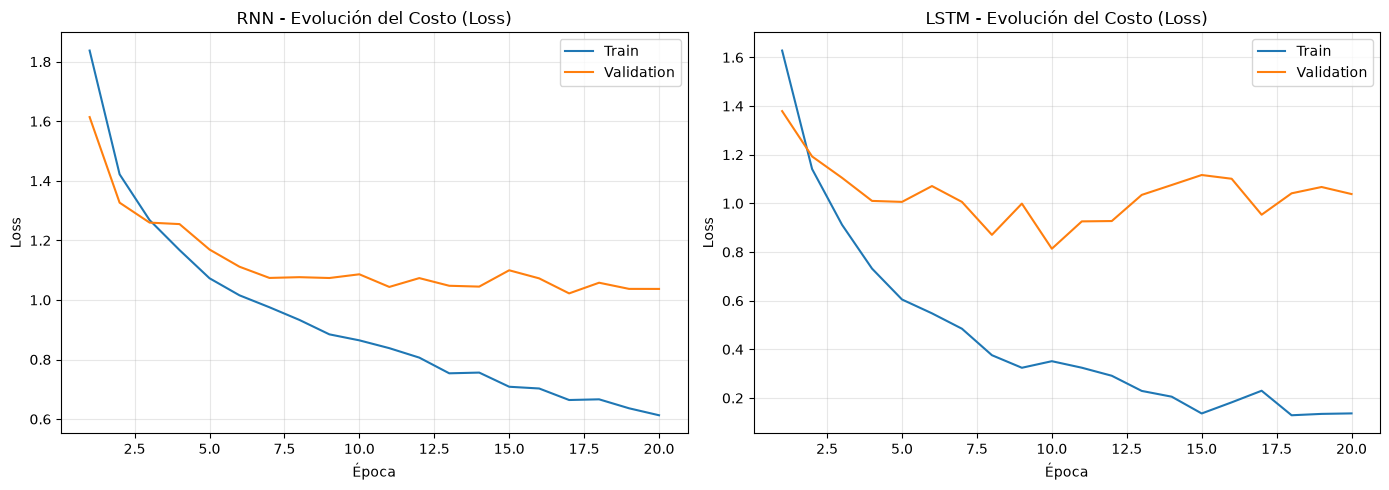

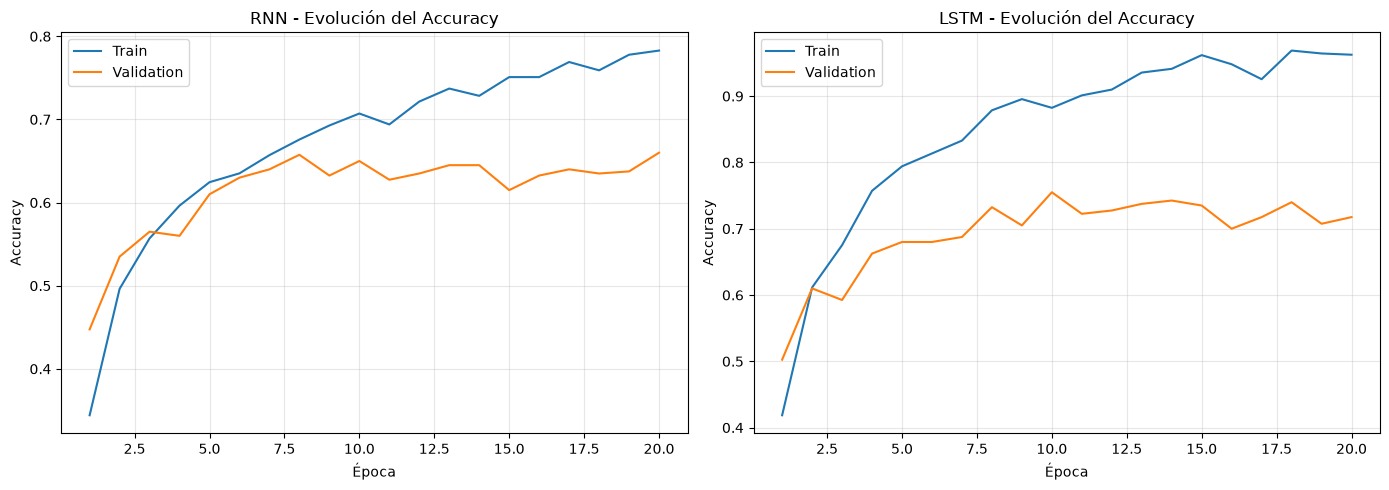

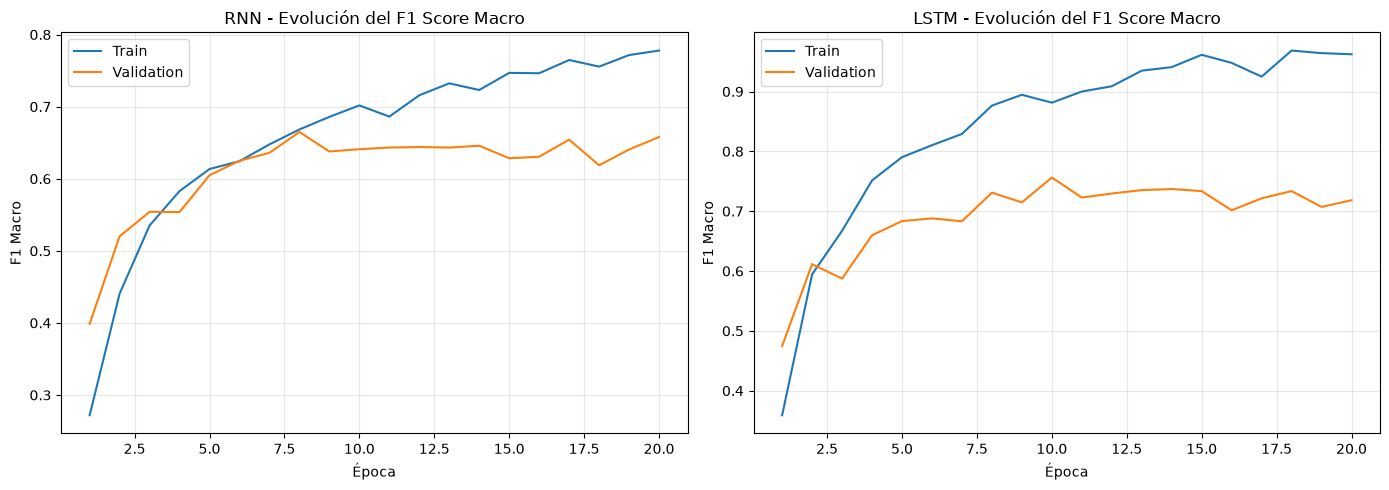

In [7]:
import matplotlib.pyplot as plt

def plot_metric(rnn_history, lstm_history, metric_key, ylabel, title):
    epochs_range = range(1, len(rnn_history[f"train_{metric_key}"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs_range, rnn_history[f"train_{metric_key}"], label="Train")
    axes[0].plot(epochs_range, rnn_history[f"val_{metric_key}"], label="Validation")
    axes[0].set_title(f"RNN - {title}")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel(ylabel)
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_range, lstm_history[f"train_{metric_key}"], label="Train")
    axes[1].plot(epochs_range, lstm_history[f"val_{metric_key}"], label="Validation")
    axes[1].set_title(f"LSTM - {title}")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel(ylabel)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Loss
plot_metric(rnn_history, lstm_history, "loss", "Loss", "Evolución del Costo (Loss)")

# Accuracy
plot_metric(rnn_history, lstm_history, "acc", "Accuracy", "Evolución del Accuracy")

# F1 Macro
plot_metric(rnn_history, lstm_history, "f1", "F1 Macro", "Evolución del F1 Score Macro")

In [8]:
from sklearn.metrics import classification_report

print("=== Classification Report - RNN ===")
print(classification_report(y_true_rnn, y_pred_rnn, target_names=GENRES))

print("\n=== Classification Report - LSTM ===")
print(classification_report(y_true_lstm, y_pred_lstm, target_names=GENRES))

=== Classification Report - RNN ===
              precision    recall  f1-score   support

       blues       0.54      0.76      0.63        42
   classical       0.85      0.92      0.88        24
     country       0.58      0.58      0.58        48
       disco       0.56      0.66      0.60        44
      hiphop       0.53      0.70      0.60        30
        jazz       0.85      0.74      0.79        54
       metal       0.94      0.83      0.88        36
         pop       0.72      0.74      0.73        38
      reggae       0.83      0.43      0.57        44
        rock       0.41      0.35      0.38        40

    accuracy                           0.66       400
   macro avg       0.68      0.67      0.66       400
weighted avg       0.68      0.66      0.66       400


=== Classification Report - LSTM ===
              precision    recall  f1-score   support

       blues       0.80      0.79      0.80        42
   classical       0.85      0.96      0.90        24
    

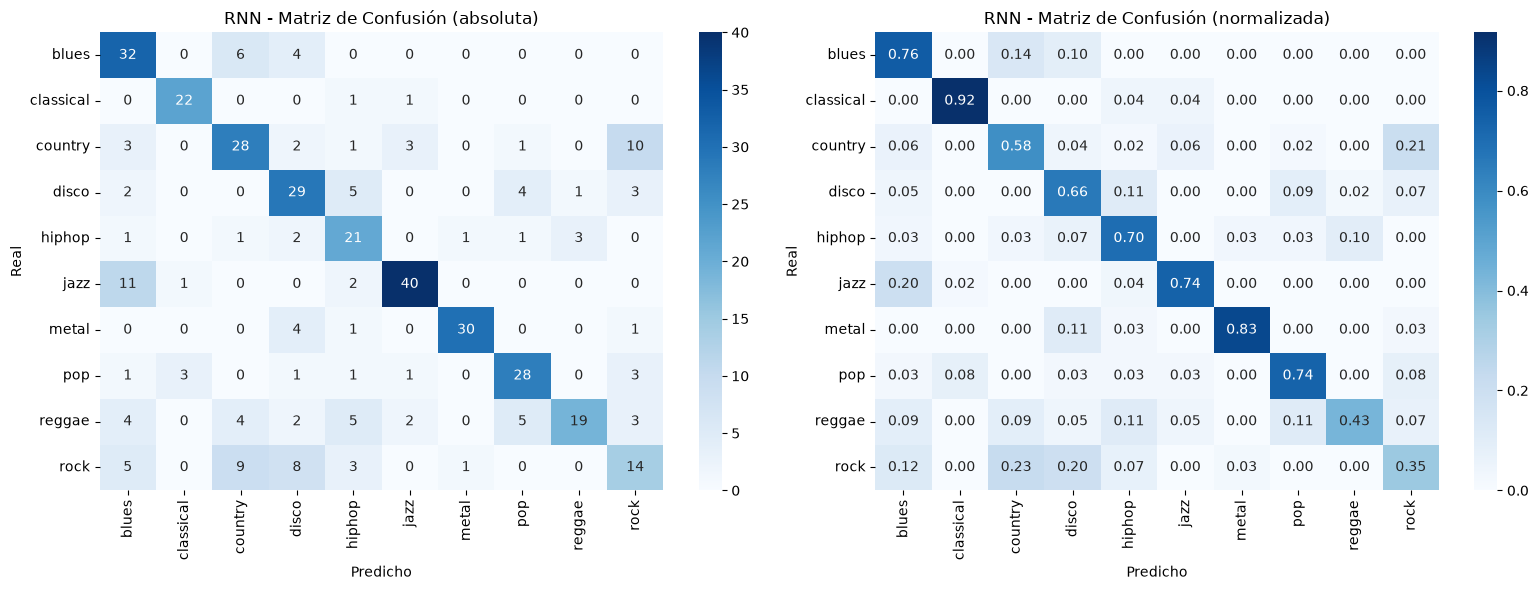

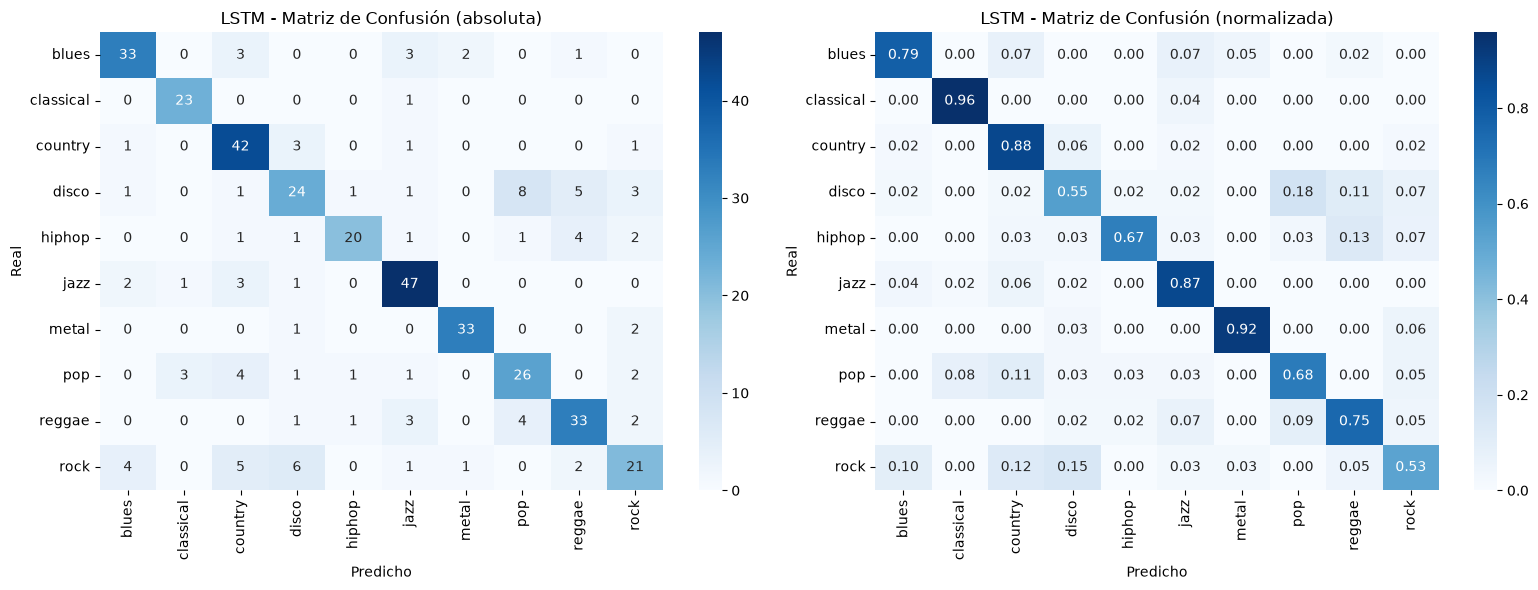

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrices(y_true, y_pred, genres, model_name):
    cm_abs = confusion_matrix(y_true, y_pred)
    cm_norm = confusion_matrix(y_true, y_pred, normalize="true")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(cm_abs, annot=True, fmt="d", cmap="Blues",
                xticklabels=genres, yticklabels=genres, ax=axes[0])
    axes[0].set_title(f"{model_name} - Matriz de Confusión (absoluta)")
    axes[0].set_xlabel("Predicho")
    axes[0].set_ylabel("Real")

    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=genres, yticklabels=genres, ax=axes[1])
    axes[1].set_title(f"{model_name} - Matriz de Confusión (normalizada)")
    axes[1].set_xlabel("Predicho")
    axes[1].set_ylabel("Real")

    plt.tight_layout()
    plt.show()

plot_confusion_matrices(y_true_rnn, y_pred_rnn, GENRES, "RNN")
plot_confusion_matrices(y_true_lstm, y_pred_lstm, GENRES, "LSTM")

In [10]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Modelo": ["RNN", "LSTM"],
    "Accuracy (val)": [final_val_acc_rnn, final_val_acc_lstm],
    "F1 Macro (val)": [final_val_f1_rnn, final_val_f1_lstm],
    "Loss final (val)": [rnn_history["val_loss"][-1], lstm_history["val_loss"][-1]],
    "Parámetros totales": [
        sum(p.numel() for p in rnn_model.parameters()),
        sum(p.numel() for p in lstm_model.parameters()),
    ],
})

comparison_df

,Modelo,Accuracy (val),F1 Macro (val),Loss final (val),Parámetros totales
0,RNN,0.6575,0.664841,1.036984,25610
1,LSTM,0.7550,0.756304,1.038193,98570


### Comparativa y modelo ganador

A partir de la tabla anterior, el modelo **LSTM** obtuvo mejor Accuracy y F1 Macro en validación (0.7563 y 0.7550 respectivamente, frente a 0.6575 y 0.6648 de la RNN), además de un loss final levemente más bajo (1.037 vs 1.038). Si bien la LSTM tiene aproximadamente 4 veces más parámetros que la RNN (98,570 vs 25,610), la diferencia de desempeño justifica la mayor complejidad del modelo en este caso. Esto es consistente con lo esperado teóricamente: las compuertas de la LSTM le permiten regular mejor qué información retener u olvidar a lo largo de la secuencia, una ventaja que se vuelve más relevante en secuencias de 650 pasos temporales, donde la RNN clásica es más propensa a perder información de pasos tempranos incluso con mean-pooling.

Cabe destacar que, en corridas distintas del mismo pipeline, ambos modelos mostraron rendimientos relativamente cercanos entre sí (con la RNN incluso superando a la LSTM en alguna corrida), lo cual sugiere que la diferencia de performance entre ambas arquitecturas no es enorme para este problema puntual, y que con un conjunto de validación de ~400 muestras hay cierto margen de variabilidad entre ejecuciones.

Se selecciona **LSTM** como modelo final, y será el utilizado en la sección 4 para la prueba con canciones nuevas.

In [13]:
import os
from IPython.display import Audio, display
import torch.nn.functional as F

NEW_SET_PATH = "new_set"

# ----------------------------
# Preprocesamiento EXACTO al de entrenamiento (mismo T_MAX que los chunks)
# ----------------------------
def preprocess_new_song(file_path, sr=SR, n_mfcc=N_MFCC, t_max=T_MAX):
    y_audio, _ = librosa.load(file_path, sr=sr, duration=DURATION)
    y_audio = y_audio / (np.max(np.abs(y_audio)) + 1e-8)  # normalización de amplitud simple
    mfcc = librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=n_mfcc).T  # (T, n_mfcc)

    if mfcc.shape[0] < t_max:
        mfcc = np.pad(mfcc, ((0, t_max - mfcc.shape[0]), (0, 0)), mode="constant")
    else:
        mfcc = mfcc[:t_max, :]

    mfcc = mfcc.astype(np.float32)

    # Normalización con las MISMAS estadísticas de train
    mfcc_norm = (mfcc - mean.squeeze()) / (std.squeeze() + 1e-8)

    return mfcc_norm

# ----------------------------
# Inferencia sobre el modelo ganador (LSTM)
# ----------------------------
winner_model = lstm_model
winner_model.eval()

resultados = []

for genre in GENRES:
    genre_path = os.path.join(NEW_SET_PATH, genre)
    if not os.path.isdir(genre_path):
        print(f"⚠️ No se encontró carpeta para el género: {genre}")
        continue

    archivos_mp3 = [f for f in os.listdir(genre_path) if f.endswith(".mp3")]
    if len(archivos_mp3) == 0:
        print(f"⚠️ No hay archivos .mp3 en {genre_path}")
        continue

    for fname in archivos_mp3:
        file_path = os.path.join(genre_path, fname)

        mfcc_norm = preprocess_new_song(file_path)
        x_tensor = torch.tensor(mfcc_norm, dtype=torch.float32).unsqueeze(0)  # (1, T_MAX, N_MFCC)

        with torch.no_grad():
            logits = winner_model(x_tensor.to(device))
            probs = F.softmax(logits, dim=1).squeeze().cpu().numpy()

        pred_idx = probs.argmax()
        pred_genre = GENRES[pred_idx]

        resultados.append({
            "archivo": fname,
            "genero_esperado": genre,
            "genero_predicho": pred_genre,
            "correcto": genre == pred_genre,
            "probs": probs,
        })

        # print(f"\n{'='*60}")
        # print(f"Canción: {fname}")
        # print(f"Género esperado:  {genre}")
        # print(f"Género predicho:  {pred_genre}  {'✅' if genre == pred_genre else '❌'}")
        # print(f"\nScores por género:")
        # for g, p in sorted(zip(GENRES, probs), key=lambda x: -x[1]):
        #    print(f"  {g:12s} {p*100:5.1f}%")

        #display(Audio(file_path))

print(f"\n{'='*60}")
n_correctas = sum(r["correcto"] for r in resultados)
print(f"Accuracy sobre canciones nuevas: {n_correctas}/{len(resultados)} = {n_correctas/len(resultados)*100:.1f}%")


Accuracy sobre canciones nuevas: 7/10 = 70.0%


In [14]:
import pandas as pd
from collections import Counter

# ----------------------------
# Tabla resumen de todos los resultados
# ----------------------------
df_resultados = pd.DataFrame([
    {
        "archivo": r["archivo"],
        "esperado": r["genero_esperado"],
        "predicho": r["genero_predicho"],
        "correcto": r["correcto"],
        "confianza_predicha": r["probs"][GENRES.index(r["genero_predicho"])],
        "score_esperado": r["probs"][GENRES.index(r["genero_esperado"])],
    }
    for r in resultados
])

print("=== Tabla completa de resultados ===")
display(df_resultados)

# ----------------------------
# Casos donde el modelo se equivocó
# ----------------------------
errores = df_resultados[~df_resultados["correcto"]]

print(f"\n=== Análisis de errores ({len(errores)}/{len(df_resultados)} canciones mal clasificadas) ===\n")

if len(errores) == 0:
    print("¡El modelo clasificó correctamente todas las canciones nuevas!")
else:
    for _, row in errores.iterrows():
        print(f"🎵 {row['archivo']}")
        print(f"   Esperado: {row['esperado']}  →  Predicho: {row['predicho']}")
        print(f"   Confianza en la predicción incorrecta: {row['confianza_predicha']*100:.1f}%")
        print(f"   Score que le dio al género correcto:    {row['score_esperado']*100:.1f}%")
        print()

# ----------------------------
# Pares de confusión más frecuentes
# ----------------------------
if len(errores) > 0:
    pares_confusion = Counter(zip(errores["esperado"], errores["predicho"]))
    print("=== Pares de confusión (esperado → predicho) ===")
    for (esperado, predicho), count in pares_confusion.most_common():
        print(f"  {esperado} → {predicho}: {count} caso(s)")

# ----------------------------
# Confianza promedio: aciertos vs errores
# ----------------------------
if len(errores) > 0:
    conf_aciertos = df_resultados[df_resultados["correcto"]]["confianza_predicha"].mean()
    conf_errores = errores["confianza_predicha"].mean()
    print(f"\n=== Confianza promedio del modelo ===")
    print(f"En aciertos: {conf_aciertos*100:.1f}%")
    print(f"En errores:  {conf_errores*100:.1f}%")

=== Tabla completa de resultados ===


,archivo,esperado,predicho,correcto,confianza_predicha,score_esperado
0,Beer Belly Blues - John Deley.mp3,blues,blues,True,0.512352,0.512352
1,Achachak - First Movement.mp3,classical,classical,True,0.985028,0.985028
2,Country Music - Hugh Mitchel.mp3,country,country,True,0.705475,0.705475
3,SyncLab Music.mp3,disco,disco,True,0.573360,0.573360
4,Flicker - Max Surla_Media Right Productions.mp3,hiphop,hiphop,True,0.981303,0.981303
5,Soundore - Jazz.mp3,jazz,jazz,True,0.998865,0.998865
6,Back and Forth - Silent Partner.mp3,metal,rock,False,0.928642,0.030079
7,SyncLab Music - Pop.mp3,pop,disco,False,0.573360,0.135681
8,GOYMAMBA - Reggae life.mp3,reggae,reggae,True,0.774079,0.774079
9,All About Me - Blue Deer Studio.mp3,rock,blues,False,0.545998,0.001261



=== Análisis de errores (3/10 canciones mal clasificadas) ===

🎵 Back and Forth - Silent Partner.mp3
   Esperado: metal  →  Predicho: rock
   Confianza en la predicción incorrecta: 92.9%
   Score que le dio al género correcto:    3.0%

🎵 SyncLab Music - Pop.mp3
   Esperado: pop  →  Predicho: disco
   Confianza en la predicción incorrecta: 57.3%
   Score que le dio al género correcto:    13.6%

🎵 All About Me - Blue Deer Studio.mp3
   Esperado: rock  →  Predicho: blues
   Confianza en la predicción incorrecta: 54.6%
   Score que le dio al género correcto:    0.1%

=== Pares de confusión (esperado → predicho) ===
  metal → rock: 1 caso(s)
  pop → disco: 1 caso(s)
  rock → blues: 1 caso(s)

=== Confianza promedio del modelo ===
En aciertos: 79.0%
En errores:  68.3%
